# Monochromatic currents and Figures 4-5

This section provides the code for computing the **transmission coefficient** (Sec. II, Eq. 8,9).  
The necessary simulating/plotting functions are included in an external helper Python file, which is imported directly.

### Contents (ordered as in the notebook)
- Definition of the **emissivity profile**  
- Code to reproduce **Figure 5**
- Code and data used for **Figure 4** and **Figure 5** 
  - Reciprocal / Non-reciprocal (on-off continous)
  - Equilibrium and non-equilibrium cases. 
  - on-off spurious result

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.patches as patches
import importlib
import helper_currents

#fancy plot setting
os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"
plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 25  
plt.rcParams['axes.titlesize'] = 25  

#reload library in case of updates.
importlib.reload(helper_currents)
from helper_currents import *

In [3]:
#On-Off emissivity profile
def e(theta, phi, alpha):
    #we scale phi to [0, 2pi]
    if theta < 0:
        theta = -theta 
        phi = phi + np.pi 
    
    phi = phi % (2 * np.pi)  
    if phi > np.pi/2 and phi < 3/2*np.pi: 
        return 0
    else:
        return 1
            
def a(theta, phi, alpha):
    return e(theta, phi + np.pi, alpha)

def R(theta, phi, alpha):
    return 1 - a(theta, phi, alpha)    

Simulation done in 132.184 seconds


<Figure size 2400x2400 with 0 Axes>

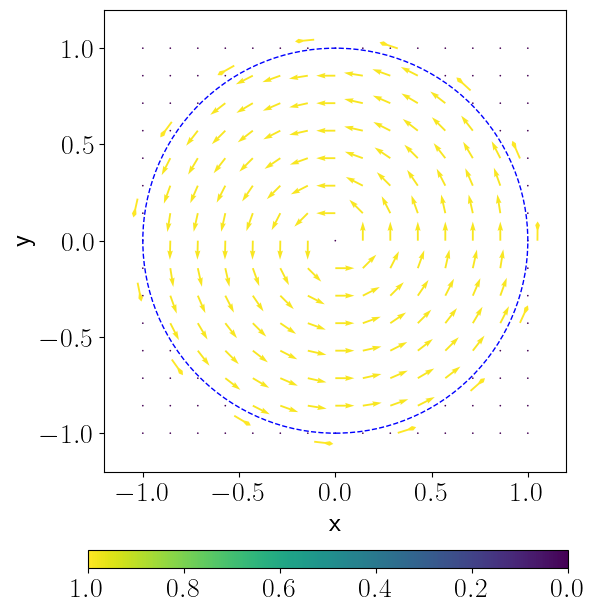

In [4]:
tol = 10**(-2) #Ray decay tolerance. 
dpi_alpha_values = 15 # Number of arrows in the contour.
dpi_x_values = 15 # Plot inside the circle
dpi_y_values = dpi_x_values 
dpi_angles = 100 #Scattering angles. 

U,V, U_contour, V_contour = heat_current_vector_field_plotter(dpi_x_values, dpi_y_values, dpi_angles, dpi_alpha_values, tol, e, a, R)

## Plots for Figures 4 and 5

The following cells load the data and generate the plot corresponding to **Figure 4** and **Figure 5**.

In [5]:
U_loaded_1 = np.load('data/Inner_U_equilibrium_reciprocal_17.npy')
V_loaded_1 = np.load('data/Inner_V_equilibrium_reciprocal_17.npy')
U_contour_loaded_1 = np.load('data/Contour_U_equilibrium_reciprocal_17.npy')
V_contour_loaded_1 = np.load('data/Contour_V_equilibrium_reciprocal_17.npy')

U_loaded_2 = np.load('data/Inner_U_equilibrium_non_reciprocal_17.npy')
V_loaded_2 = np.load('data/Inner_V_equilibrium_non_reciprocal_17.npy')
U_contour_loaded_2 = np.load('data/Contour_U_equilibrium_non_reciprocal_17.npy')
V_contour_loaded_2 = np.load('data/Contour_V_equilibrium_non_reciprocal_17.npy')

U_loaded_3 = np.load('data/Inner_U_non_equilibrium_reciprocal_16.npy')
V_loaded_3 = np.load('data/Inner_V_non_equilibrium_reciprocal_16.npy')
U_contour_loaded_3 = np.load('data/Contour_U_non_equilibrium_reciprocal_16.npy')
V_contour_loaded_3 = np.load('data/Contour_V_non_equilibrium_reciprocal_16.npy')

U_loaded_4 = np.load('data/Inner_U_non_equilibrium_non_reciprocal_17.npy')
V_loaded_4 = np.load('data/Inner_V_non_equilibrium_non_reciprocal_17.npy')
U_contour_loaded_4 = np.load('data/Contour_U_non_equilibrium_non_reciprocal_17.npy')
V_contour_loaded_4 = np.load('data/Contour_V_non_equilibrium_non_reciprocal_17.npy')

U_loaded_list = [U_loaded_1, U_loaded_2, U_loaded_3, U_loaded_4]
V_loaded_list = [V_loaded_1, V_loaded_2, V_loaded_3, V_loaded_4]
U_contour_list = [U_contour_loaded_1, U_contour_loaded_2, U_contour_loaded_3, U_contour_loaded_4]
V_contour_list = [V_contour_loaded_1, V_contour_loaded_2, V_contour_loaded_3, V_contour_loaded_4]

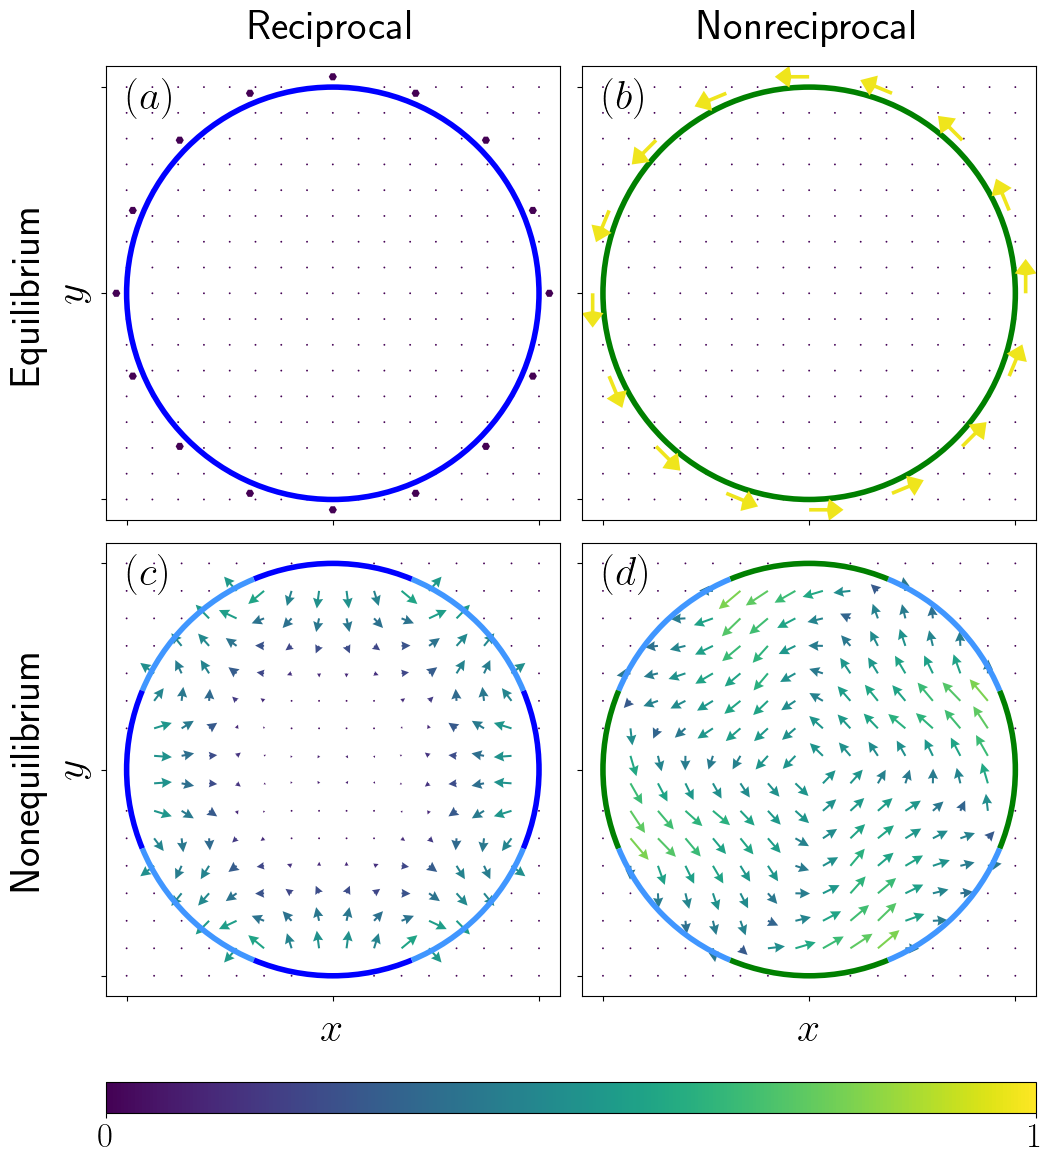

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 14), dpi=100, sharex=True, sharey=True)
axes = axes.ravel()
labels = [r'$(a)$', r'$(b)$', r'$(c)$', r'$(d)$']

#constants (for fancy stlye)
headwidths   = [7, 6, 5, 5]
headlengths  = [6, 4, 5, 5]
inner_width  = 0.0045
contour_wfac = [0.003, 0.002, 0.001, 0.001]
cmap = 'viridis'
norm = Normalize(0, 1) #(for colors)

# global scale display 
global_scale = 6 * max(
    max(np.hypot(U_loaded_list[k],   V_loaded_list[k]).max()   for k in range(len(U_loaded_list))),
    max(np.hypot(U_contour_list[k],  V_contour_list[k]).max()  for k in range(len(U_contour_list)))
)

def draw_boundary(ax, idx, lw=4):
    if idx == 0:
        ax.add_artist(plt.Circle((0, 0), 1, color='blue',  fill=False, linewidth=lw))
    elif idx == 1:
        ax.add_artist(plt.Circle((0, 0), 1, color='green', fill=False, linewidth=lw))
    else:
        if idx == 2:
            colors = ['blue', '#4096ffff']  
        else: 
            colors = ['green', '#4096ffff']

        for k in range(8):
            theta1 = k * 45 - 22.5
            theta2 = (k + 1) * 45 - 22.5
            ax.add_patch(patches.Arc((0, 0), 2, 2, theta1=theta1, theta2=theta2,
                                     color=colors[k % 2], linewidth=lw))

for idx, ax in enumerate(axes):
    # Inner currents
    n = len(U_loaded_list[idx])
    x = np.linspace(-1, 1, n)
    y = np.linspace(-1, 1, n)

    mag = np.hypot(U_loaded_list[idx], V_loaded_list[idx])
    ax.quiver(x, y, U_loaded_list[idx], V_loaded_list[idx], mag,
              cmap=cmap, norm=norm, scale=global_scale, scale_units='xy',
              headwidth=headwidths[idx], headlength=headlengths[idx], width=inner_width)

    # Contour arrows (only at equilibrium)
    if idx < 2:
        m = len(U_contour_list[idx])
        alpha = np.linspace(0, 2 * np.pi, m, endpoint=False)
        xc, yc = 1.05 * np.cos(alpha), 1.05 * np.sin(alpha)
        magc = np.hypot(U_contour_list[idx], V_contour_list[idx])
        ax.quiver(xc, yc, U_contour_list[idx], V_contour_list[idx], magc,
                  cmap=cmap, norm=norm, scale=global_scale, scale_units='xy',
                  width=contour_wfac[idx] * headlengths[idx],
                  headwidth=headwidths[idx], headlength=headlengths[idx], zorder=2)

    # fancy plot
    draw_boundary(ax, idx)
    ax.set(xlim=(-1.1, 1.1), ylim=(-1.1, 1.1), xticks=[-1, 0, 1], yticks=[-1, 0, 1])
    ax.set_aspect('equal', adjustable='box')
    r, c = divmod(idx, 2)
    if r == 1: ax.set_xlabel(r'$x$', fontsize=30)
    if c == 0: ax.set_ylabel(r'$y$', fontsize=30)
    if r == 0: ax.set_xticklabels([])
    if c == 1: ax.set_yticklabels([])
    ax.tick_params(labelsize=25)
    ax.text(-1.0, 1.05, labels[idx], fontsize=30, fontweight='bold', va='top', ha='left')

plt.subplots_adjust(wspace=0.05, hspace=0.05, bottom=0.12)

# colorbar
mappable = ScalarMappable(norm=norm, cmap=cmap)
cbar = fig.colorbar(mappable, ax=axes.tolist(), orientation='horizontal', pad=0.08, fraction=0.046, aspect=30)
cbar.set_ticks([0, 1])
cbar.ax.tick_params(labelsize=25)

# headings
pos00, pos01, pos10, pos11 = [ax.get_position() for ax in axes]
x_center_left  = 0.5 * (pos00.x0 + pos00.x1)
x_center_right = 0.5 * (pos01.x0 + pos01.x1)
y_top = max(pos00.y1, pos01.y1) + 0.02
fig.text(x_center_left,  y_top, 'Reciprocal',     fontsize=30, ha='center')
fig.text(x_center_right, y_top, 'Nonreciprocal',  fontsize=30, ha='center')

y_center_top    = 0.5 * (pos00.y0 + pos00.y1)
y_center_bottom = 0.5 * (pos10.y0 + pos10.y1)
x_side = min(pos00.x0, pos10.x0) - 0.08
fig.text(x_side, y_center_top,    'Equilibrium',    fontsize=30, va='center', rotation='vertical')
fig.text(x_side, y_center_bottom, 'Nonequilibrium', fontsize=30, va='center', rotation='vertical')

plt.savefig('figures/monochromatic_currents.pdf', format='pdf', bbox_inches='tight')
plt.show()


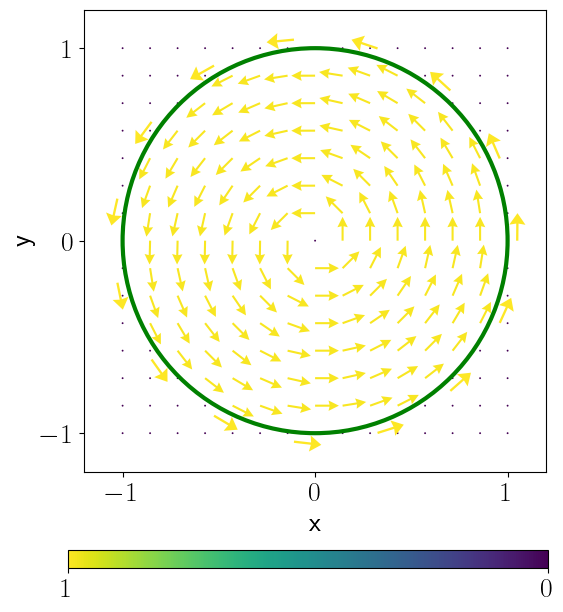

In [8]:
U = np.load("data/Inner_U_on_off.npy")
V = np.load("data/Inner_V_on_off.npy")
U_contour = np.load("data/Contour_U_on_off.npy")
V_contour = np.load("data/Contour_V_on_off.npy")

#inner and contour mesh.grid for the plot
ny, nx = U.shape
x_values = np.linspace(-1, 1, nx)
y_values = np.linspace(-1, 1, ny)

m = len(U_contour)
alpha_values = np.linspace(0, 2*np.pi, m, endpoint=False)
x_values_contour = 1.05 * np.cos(alpha_values)
y_values_contour = 1.05 * np.sin(alpha_values)

#magnitude for coloring
magnitude = np.hypot(U, V)
magnitude_contour = np.hypot(U_contour, V_contour)
global_max = 10 * max(magnitude.max(), magnitude_contour.max())


fig, ax = plt.subplots(figsize=(6, 6), dpi=100)
#inner currents
quiv = ax.quiver(
    x_values, y_values, U, V, magnitude,
    cmap='viridis', scale= 0.8 * global_max, scale_units='xy', headlength = 5, headwidth = 5, width = 0.0045)
quiv.set_clim(0, 1)

#contour currents 
quiv_cont = ax.quiver(
    x_values_contour, y_values_contour, U_contour, V_contour, magnitude_contour,
    cmap='viridis', scale= 0.7 * global_max, scale_units='xy',
    width=0.005, headwidth=7, headlength=5
)
quiv_cont.set_clim(0, 1)

# horizontal colorbar 
cbar_ax = fig.add_axes([0.10, -0.05, 0.8, 0.03])
cbar = fig.colorbar(quiv_cont, cax=cbar_ax, orientation='horizontal')
cbar.set_label('', fontsize=20, rotation=0, labelpad=10)
cbar.ax.tick_params(labelsize=20)
cbar.set_ticks(cbar.get_ticks()[::1])
cbar.ax.invert_xaxis()
cbar.set_ticks([0,1])

#fancy styles
circle = plt.Circle((0, 0), 1, color='green', fill=False, linestyle='-', linewidth = 3)
ax.add_artist(circle)

ax.set_xlim([-1.2, 1.2])
ax.set_xticks([-1,0,1])
ax.set_ylim([-1.2, 1.2])
ax.set_yticks([-1,0,1])
ax.set_xlabel('x', fontsize=20)
ax.set_ylabel('y', fontsize=20)
ax.tick_params(labelsize=20)
ax.set_aspect('equal')

plt.savefig('figures/on_off_monochromatic_currents.pdf', format = 'pdf', bbox_inches = 'tight')
plt.show()